## Unit 6 Exercise

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    logging,
)
import evaluate
from datasets import load_dataset
from sklearn.decomposition import PCA


In [2]:
model_name = "distilbert-base-uncased"

id2label = {0: "full-time", 1: "part-time", 2: "contract"}
label2id = {v: k for k, v in id2label.items()}

tokenizer = AutoTokenizer.from_pretrained(model_name)

logging.set_verbosity_error()
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True
)
logging.set_verbosity_warning()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

In [3]:
ds = load_dataset("will4381/job-posting-classification", split="train")

In [4]:
def normalize_label(example):
    et = (example["employment_type"] or "").lower()
    if "part" in et:   example["label"] = 1
    elif "contract" in et or "locum" in et: example["label"] = 2
    elif "full" in et: example["label"] = 0
    else:              example["label"] = -1
    example["text"] = (example["job_responsibilities"] or "").strip()
    return example

ds = ds.map(normalize_label)
ds = ds.filter(lambda x: x["label"] != -1 and len(x["text"]) > 10)
ds = ds.select_columns(["text", "label"])


In [5]:
ds = ds.shuffle(seed=42).select(range(1000))
split = ds.train_test_split(test_size=0.2, seed=42)
train = split["train"]
val   = split["test"]

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

train_tokenized = train.map(tokenize_function, batched=True)
val_tokenized   = val.map(tokenize_function, batched=True)
data_collator   = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_tokenized.features.type)
print(val_tokenized.features.type)

struct<text: string, label: int64, input_ids: list<item: int32>, token_type_ids: list<item: int8>, attention_mask: list<item: int8>>
struct<text: string, label: int64, input_ids: list<item: int32>, token_type_ids: list<item: int8>, attention_mask: list<item: int8>>


In [6]:
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

training_args = TrainingArguments(
    output_dir="./job-distilbert-output",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    logging_steps=52,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.844220,0.718769,0.715000,0.670393
2,0.699790,0.685415,0.725000,0.710657
3,0.581666,0.645614,0.750000,0.691025
4,0.451003,0.597901,0.775000,0.759490
5,0.352255,0.607146,0.760000,0.747836


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.580837724685669, metrics={'train_runtime': 1567.014, 'train_samples_per_second': 2.553, 'train_steps_per_second': 0.319, 'total_flos': 128280404831616.0, 'train_loss': 0.580837724685669, 'epoch': 5.0})

In [7]:
metrics = trainer.evaluate()
print(metrics)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted
0.352255,0.597901,5,0.775000,0.759490


{'eval_loss': 0.5979005694389343, 'eval_accuracy': 0.775, 'eval_f1_weighted': 0.7594899379768865}


In [8]:
trainer.save_model("./job-distilbert-final")
tokenizer.save_pretrained("./job-distilbert-final")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./job-distilbert-final\\tokenizer_config.json',
 './job-distilbert-final\\tokenizer.json')

In [9]:
def classify_text(text, llm, tok):
    inputs = tok(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        logits = llm(**inputs).logits
    pred = logits.argmax(dim=-1).item()
    return id2label[pred]


## Evaluation

In [10]:
model_path = "./job-distilbert-final"
loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)
loaded_model     = AutoModelForSequenceClassification.from_pretrained(model_path)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [11]:
text = """
Manage a team of software engineers. Lead daily standups and sprint planning.
Review pull requests and ensure code quality. Report to CTO on project progress.
"""

label = "full-time"

output = classify_text(text, llm=loaded_model, tok=loaded_tokenizer)

print("---ORIGINAL TEXT---")
print(text)
print("-------------------")
print("-PREDICTED LABEL-")
print(output)


---ORIGINAL TEXT---

Manage a team of software engineers. Lead daily standups and sprint planning.
Review pull requests and ensure code quality. Report to CTO on project progress.

-------------------
-PREDICTED LABEL-
full-time


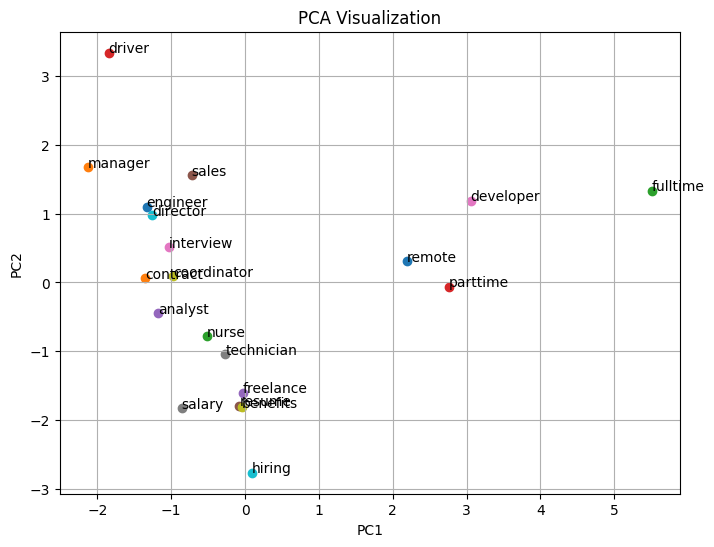

In [16]:
words = [
    "engineer", "manager", "nurse", "driver", "analyst",
    "sales", "developer", "technician", "coordinator", "director",
    "remote", "contract", "fulltime", "parttime", "freelance",
    "resume", "interview", "salary", "benefits", "hiring"
]

def get_embedding(text):
    inputs = loaded_tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = loaded_model(**inputs, output_hidden_states=True)
    embedding = outputs.hidden_states[-1].mean(dim=1)
    return embedding.squeeze().numpy()

embeddings = [get_embedding(word) for word in words]

X = np.array(embeddings)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))

for i, word in enumerate(words):
    x, y = X_pca[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y))

plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()
